# FigShare Sleep Data: Conversion & Data quality changes

This notebook handles converting the raw FigShare sleep dataset into PyEcog format

Raw format: **.dat** (sleep scores + power spectra + EEG/EMG variance + temperature) and **.eeg** (raw 200Hz EEG)

PyEcog format: separate .bin and .meta per modality (EEG, EMG, SleepScore, Temperature)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
import glob
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

warnings.filterwarnings('ignore')
# project root to import pyecog modules
sys.path.insert(0, os.path.abspath('..'))
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
from pyecog2.convert_figshare_sleep_data import readbinary_dat, convert_animal_to_multimodal

1. Data

Each .dat file has 86,400 records (one per 4-second epoch, 96 hours total).
Each record: 1 byte sleep score + 401 float32 power spectrum + 3 float32 (EEG var, EMG var, temp).

In [3]:
sleep_scores, power_spectra, eeg_var, emg_var, temperature = readbinary_dat('data/M1EXP1.dat')
power_spectra.shape

Read data/M1EXP1.dat: 86400 epochs, temp recorded: False


(86400, 401)

In [4]:
sleep_scores[:20]

'wwwwwwwwwwwwwwwwwwww'

In [5]:
(temperature != 0).any()

False

2. Data Quality: Artifact-Marked Epochs

In the dataset sleep states are manually classified:
- 'w': Wake, 'n': NREM, 'r': REM
- '1': Wake (artifact), '2': NREM (artifact), '3': REM (artifact)

The 1 / 2 / 3 states are epochs where the signal is too noisy to fully trust but have still been scored as w / nrem / rem respectively.

In [6]:
states = np.array(list(sleep_scores))
clean_mask = np.isin(states, ['w', 'n', 'r'])
artifact_mask = np.isin(states, ['1', '2', '3'])

n_total = len(states)
n_artifact = np.sum(artifact_mask)
print(f'Total epochs: {n_total:,}')
print(f'Artifact marked: {n_artifact:,} ({n_artifact/n_total*100:.1f}%)')
print(f'Normal: {np.sum(clean_mask):,} ({np.sum(clean_mask)/n_total*100:.1f}%)')

Total epochs: 86,400
Artifact marked: 2,381 (2.8%)
Normal: 84,019 (97.2%)


In [7]:
# distribution of artifact marked sleep states
artifact_labels = {'1': 'Wake (artifact)', '2': 'NREM (artifact)', '3': 'REM (artifact)'}
artifact_chars = states[artifact_mask]
unique_chars, counts = np.unique(artifact_chars, return_counts=True)

for char, count in zip(unique_chars, counts):
    pct = count / n_artifact * 100
    print(f'{artifact_labels[char]}: {count} epochs ({pct:.1f}%)')

Wake (artifact): 2289 epochs (96.1%)
NREM (artifact): 58 epochs (2.4%)
REM (artifact): 34 epochs (1.4%)


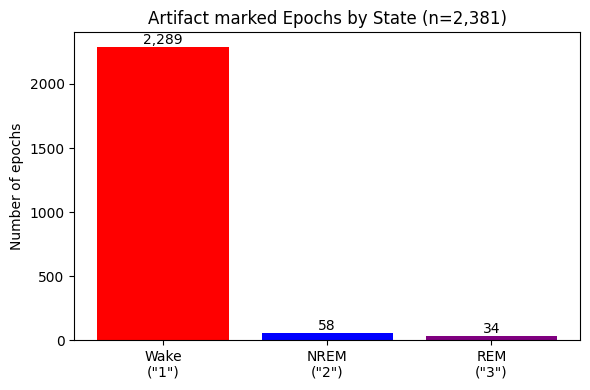

In [8]:
# distribution of artifact-marked sleep states
artifact_labels = {'1': 'Wake', '2': 'NREM', '3': 'REM'}
artifact_chars = states[artifact_mask]
unique_chars, counts = np.unique(artifact_chars, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'1': 'red', '2': 'blue', '3': 'purple'}
labels = [f'{artifact_labels[c]}\n("{c}")' for c in unique_chars]
bars = ax.bar(labels, counts, color=[colors[c] for c in unique_chars])
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('Number of epochs')
ax.set_title(f'Artifact marked Epochs by State (n={n_artifact:,})')
plt.tight_layout()
plt.show()

#tips from Johnathan for plots: seaborn for despine, also add Arial
#take into account colour blindness accessibility

Since the artifact codes (1, 2, 3) are linked to the actual sleep state, i'm mapping them to the states.

**1 -> w**, **2 -> n**, **3 -> r**. The 'artifact' flag's relevant for EEG quality analysis but not for sleep state classification.

In [9]:
def map_artifact_to_state(sleep_scores):
    mapping = {'1': 'w', '2': 'n', '3': 'r'}
    return np.array([mapping.get(s, s) for s in sleep_scores])

In [10]:
mapped = map_artifact_to_state(list(sleep_scores))
n_remaining = np.sum(~np.isin(mapped, ['w', 'n', 'r']))
n_remaining

0

In [11]:
print('distribution before vs after mapping')
for state, name in [('w', 'Wake'), ('n', 'NREM'), ('r', 'REM')]:
    before = np.sum(states == state)
    after = np.sum(mapped == state)
    print(f'{name}: {before} -> {after}')

distribution before vs after mapping
Wake: 47407 -> 49696
NREM: 32310 -> 32368
REM: 4302 -> 4336


3. Checking across multiple files/animals

In [12]:
dat_files = sorted(glob.glob('data/*.dat'))
print(f'{len(dat_files)} .dat files\n')

summary_rows = []
for dat_file in dat_files:
    animal_id = os.path.splitext(os.path.basename(dat_file))[0]
    scores, _, _, _, temp = readbinary_dat(dat_file)
    states = np.array(list(scores))
    artifact = np.isin(states, ['1', '2', '3'])
    
    summary_rows.append({
        'animal': animal_id,
        'artifacts': np.sum(artifact),
        'artifact_percent': np.sum(artifact) / len(states) * 100,
    })

summary = pd.DataFrame(summary_rows)
summary

Read data/M10EXP1.dat: 86400 epochs, temp recorded: False


38 .dat files



Read data/M11EXP1.dat: 86400 epochs, temp recorded: False
Read data/M12EXP1.dat: 86400 epochs, temp recorded: False
Read data/M13EXP1.dat: 86400 epochs, temp recorded: False
Read data/M14EXP1.dat: 86400 epochs, temp recorded: False
Read data/M15EXP1.dat: 86400 epochs, temp recorded: False
Read data/M16EXP1.dat: 86400 epochs, temp recorded: False
Read data/M17EXP1.dat: 86400 epochs, temp recorded: False
Read data/M18EXP1.dat: 86400 epochs, temp recorded: False
Read data/M19EXP1.dat: 86400 epochs, temp recorded: False
Read data/M1EXP1.dat: 86400 epochs, temp recorded: False
Read data/M1EXP2.dat: 86400 epochs, temp recorded: True
Read data/M20EXP1.dat: 86400 epochs, temp recorded: False
Read data/M21EXP1.dat: 86400 epochs, temp recorded: False
Read data/M22EXP1.dat: 86400 epochs, temp recorded: False
Read data/M23EXP1.dat: 86400 epochs, temp recorded: False
Read data/M24EXP1.dat: 86400 epochs, temp recorded: False
Read data/M25EXP1.dat: 86400 epochs, temp recorded: False
Read data/M26EXP1

,animal,artifacts,artifact_percent
0,M10EXP1,1793,2.075231
1,M11EXP1,2702,3.127315
2,M12EXP1,1340,1.550926
3,M13EXP1,978,1.131944
4,M14EXP1,831,0.961806
5,M15EXP1,5433,6.288194
6,M16EXP1,1049,1.214120
7,M17EXP1,1643,1.901620
8,M18EXP1,1514,1.752315
9,M19EXP1,2039,2.359954


4. Convert to PyEcog format

Using the conversion script to create separate `.bin` + `.meta` files per modality.

In [13]:
# convert all animals that have matching .dat + .eeg pairs
for dat_file in dat_files:
    animal_id = os.path.splitext(os.path.basename(dat_file))[0]
    eeg_file = dat_file.replace('.dat', '.eeg')
    output_folder = os.path.join('data', 'converted', animal_id)
    
    if not os.path.exists(eeg_file):
        print(f'{animal_id}: no .eeg file, skipping')
        continue
    
    created = convert_animal_to_multimodal(dat_file, eeg_file, output_folder, animal_id)
    print(f'Created: {list(created.keys())}')

Converting M10EXP1
Read data/M10EXP1.dat: 86400 epochs, temp recorded: False
Read data/M10EXP1.eeg: 69120000 samples (96.0 hours)
Created metadata file: data/converted/M10EXP1/M10EXP1_EEG_EMG.meta (modality: voltage, sample frequency: 200 Hz)
M10EXP1: temperature not recorded, skipping
Created metadata file: data/converted/M10EXP1/M10EXP1_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 41966 epochs
NREM: 37618 epochs
REM: 5023 epochs
Converting M11EXP1
Read data/M11EXP1.dat: 86400 epochs, temp recorded: False


Created: ['EEG_EMG', 'SleepScore']


Read data/M11EXP1.eeg: 69120000 samples (96.0 hours)
Created metadata file: data/converted/M11EXP1/M11EXP1_EEG_EMG.meta (modality: voltage, sample frequency: 200 Hz)
M11EXP1: temperature not recorded, skipping
Created metadata file: data/converted/M11EXP1/M11EXP1_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 46800 epochs
NREM: 31903 epochs
REM: 4995 epochs
Converting M12EXP1
Read data/M12EXP1.dat: 86400 epochs, temp recorded: False


Created: ['EEG_EMG', 'SleepScore']


Read data/M12EXP1.eeg: 69120000 samples (96.0 hours)
Created metadata file: data/converted/M12EXP1/M12EXP1_EEG_EMG.meta (modality: voltage, sample frequency: 200 Hz)
M12EXP1: temperature not recorded, skipping
Created metadata file: data/converted/M12EXP1/M12EXP1_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 43742 epochs
NREM: 37275 epochs
REM: 4043 epochs
Converting M13EXP1
Read data/M13EXP1.dat: 86400 epochs, temp recorded: False


...

Created: ['EEG_EMG', 'Temperature', 'SleepScore']


Read data/M9EXP1.dat: 86400 epochs, temp recorded: False
Read data/M9EXP1.eeg: 69120000 samples (96.0 hours)
Created metadata file: data/converted/M9EXP1/M9EXP1_EEG_EMG.meta (modality: voltage, sample frequency: 200 Hz)
M9EXP1: temperature not recorded, skipping
Created metadata file: data/converted/M9EXP1/M9EXP1_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 51094 epochs
NREM: 31240 epochs
REM: 3541 epochs
Converting M9EXP2


Created: ['EEG_EMG', 'SleepScore']


Read data/M9EXP2.dat: 86400 epochs, temp recorded: True
Read data/M9EXP2.eeg: 69120000 samples (96.0 hours)
Created metadata file: data/converted/M9EXP2/M9EXP2_EEG_EMG.meta (modality: voltage, sample frequency: 200 Hz)
Created metadata file: data/converted/M9EXP2/M9EXP2_Temperature.meta (modality: temperature, sample frequency: 0.25 Hz)
Created metadata file: data/converted/M9EXP2/M9EXP2_SleepScore.meta (modality: categorical, sample frequency: 0.25 Hz)
wake: 46710 epochs
NREM: 31546 epochs
REM: 5296 epochs


Created: ['EEG_EMG', 'Temperature', 'SleepScore']


5. artifact mapping to converted SleepScore files

I realised when opening the SleepScore.meta file in PyEcog there was a large amount of '0' values on the graph.
This is because the conversion script only recognises 'w', 'n', 'r' as valid states. When it sees artifact characters '1', '2', '3' in the raw data, they don't match any mapping and default to 0 in the .bin file. 

This step maps them to their actual states (1->wake, 2->NREM, 3->REM) and overwrites the file(s).

In [14]:
score_char_to_num = {'w': 1, 'n': 2, 'r': 3}

for dat_file in dat_files:
    animal_id = os.path.splitext(os.path.basename(dat_file))[0]
    score_path = os.path.join('data', 'converted', animal_id, f'{animal_id}_SleepScore.bin')

    scores, _, _, _, _ = readbinary_dat(dat_file)
    mapped = map_artifact_to_state(list(scores))
    mapped_numeric = np.array([score_char_to_num.get(s, 0) for s in mapped], dtype=np.uint8)
    original = np.fromfile(score_path, dtype=np.uint8)
    n_changed = np.sum(original != mapped_numeric)
    
    mapped_numeric.tofile(score_path)

Read data/M10EXP1.dat: 86400 epochs, temp recorded: False
Read data/M11EXP1.dat: 86400 epochs, temp recorded: False
Read data/M12EXP1.dat: 86400 epochs, temp recorded: False
Read data/M13EXP1.dat: 86400 epochs, temp recorded: False
Read data/M14EXP1.dat: 86400 epochs, temp recorded: False
Read data/M15EXP1.dat: 86400 epochs, temp recorded: False
Read data/M16EXP1.dat: 86400 epochs, temp recorded: False
Read data/M17EXP1.dat: 86400 epochs, temp recorded: False
Read data/M18EXP1.dat: 86400 epochs, temp recorded: False
Read data/M19EXP1.dat: 86400 epochs, temp recorded: False
Read data/M1EXP1.dat: 86400 epochs, temp recorded: False
Read data/M1EXP2.dat: 86400 epochs, temp recorded: True
Read data/M20EXP1.dat: 86400 epochs, temp recorded: False
Read data/M21EXP1.dat: 86400 epochs, temp recorded: False
Read data/M22EXP1.dat: 86400 epochs, temp recorded: False
Read data/M23EXP1.dat: 86400 epochs, temp recorded: False
Read data/M24EXP1.dat: 86400 epochs, temp recorded: False
Read data/M25EXP1

FileNotFoundError: [Errno 2] No such file or directory: 'data/converted/M3EXP1/M3EXP1_SleepScore.bin'

6. Checking temp data for EXP2 files as they are the only ones with temperature data

In [ ]:
temp_files = sorted(glob.glob('data/converted/M*EXP2/*Temperature*.bin'))
for f in temp_files:
    data = np.fromfile(f, dtype=np.float32)
    print(f'{os.path.basename(f)}: {len(data)} samples, '
          f'range = [{data.min():.2f}, {data.max():.2f}], mean = {data.mean():.2f}')

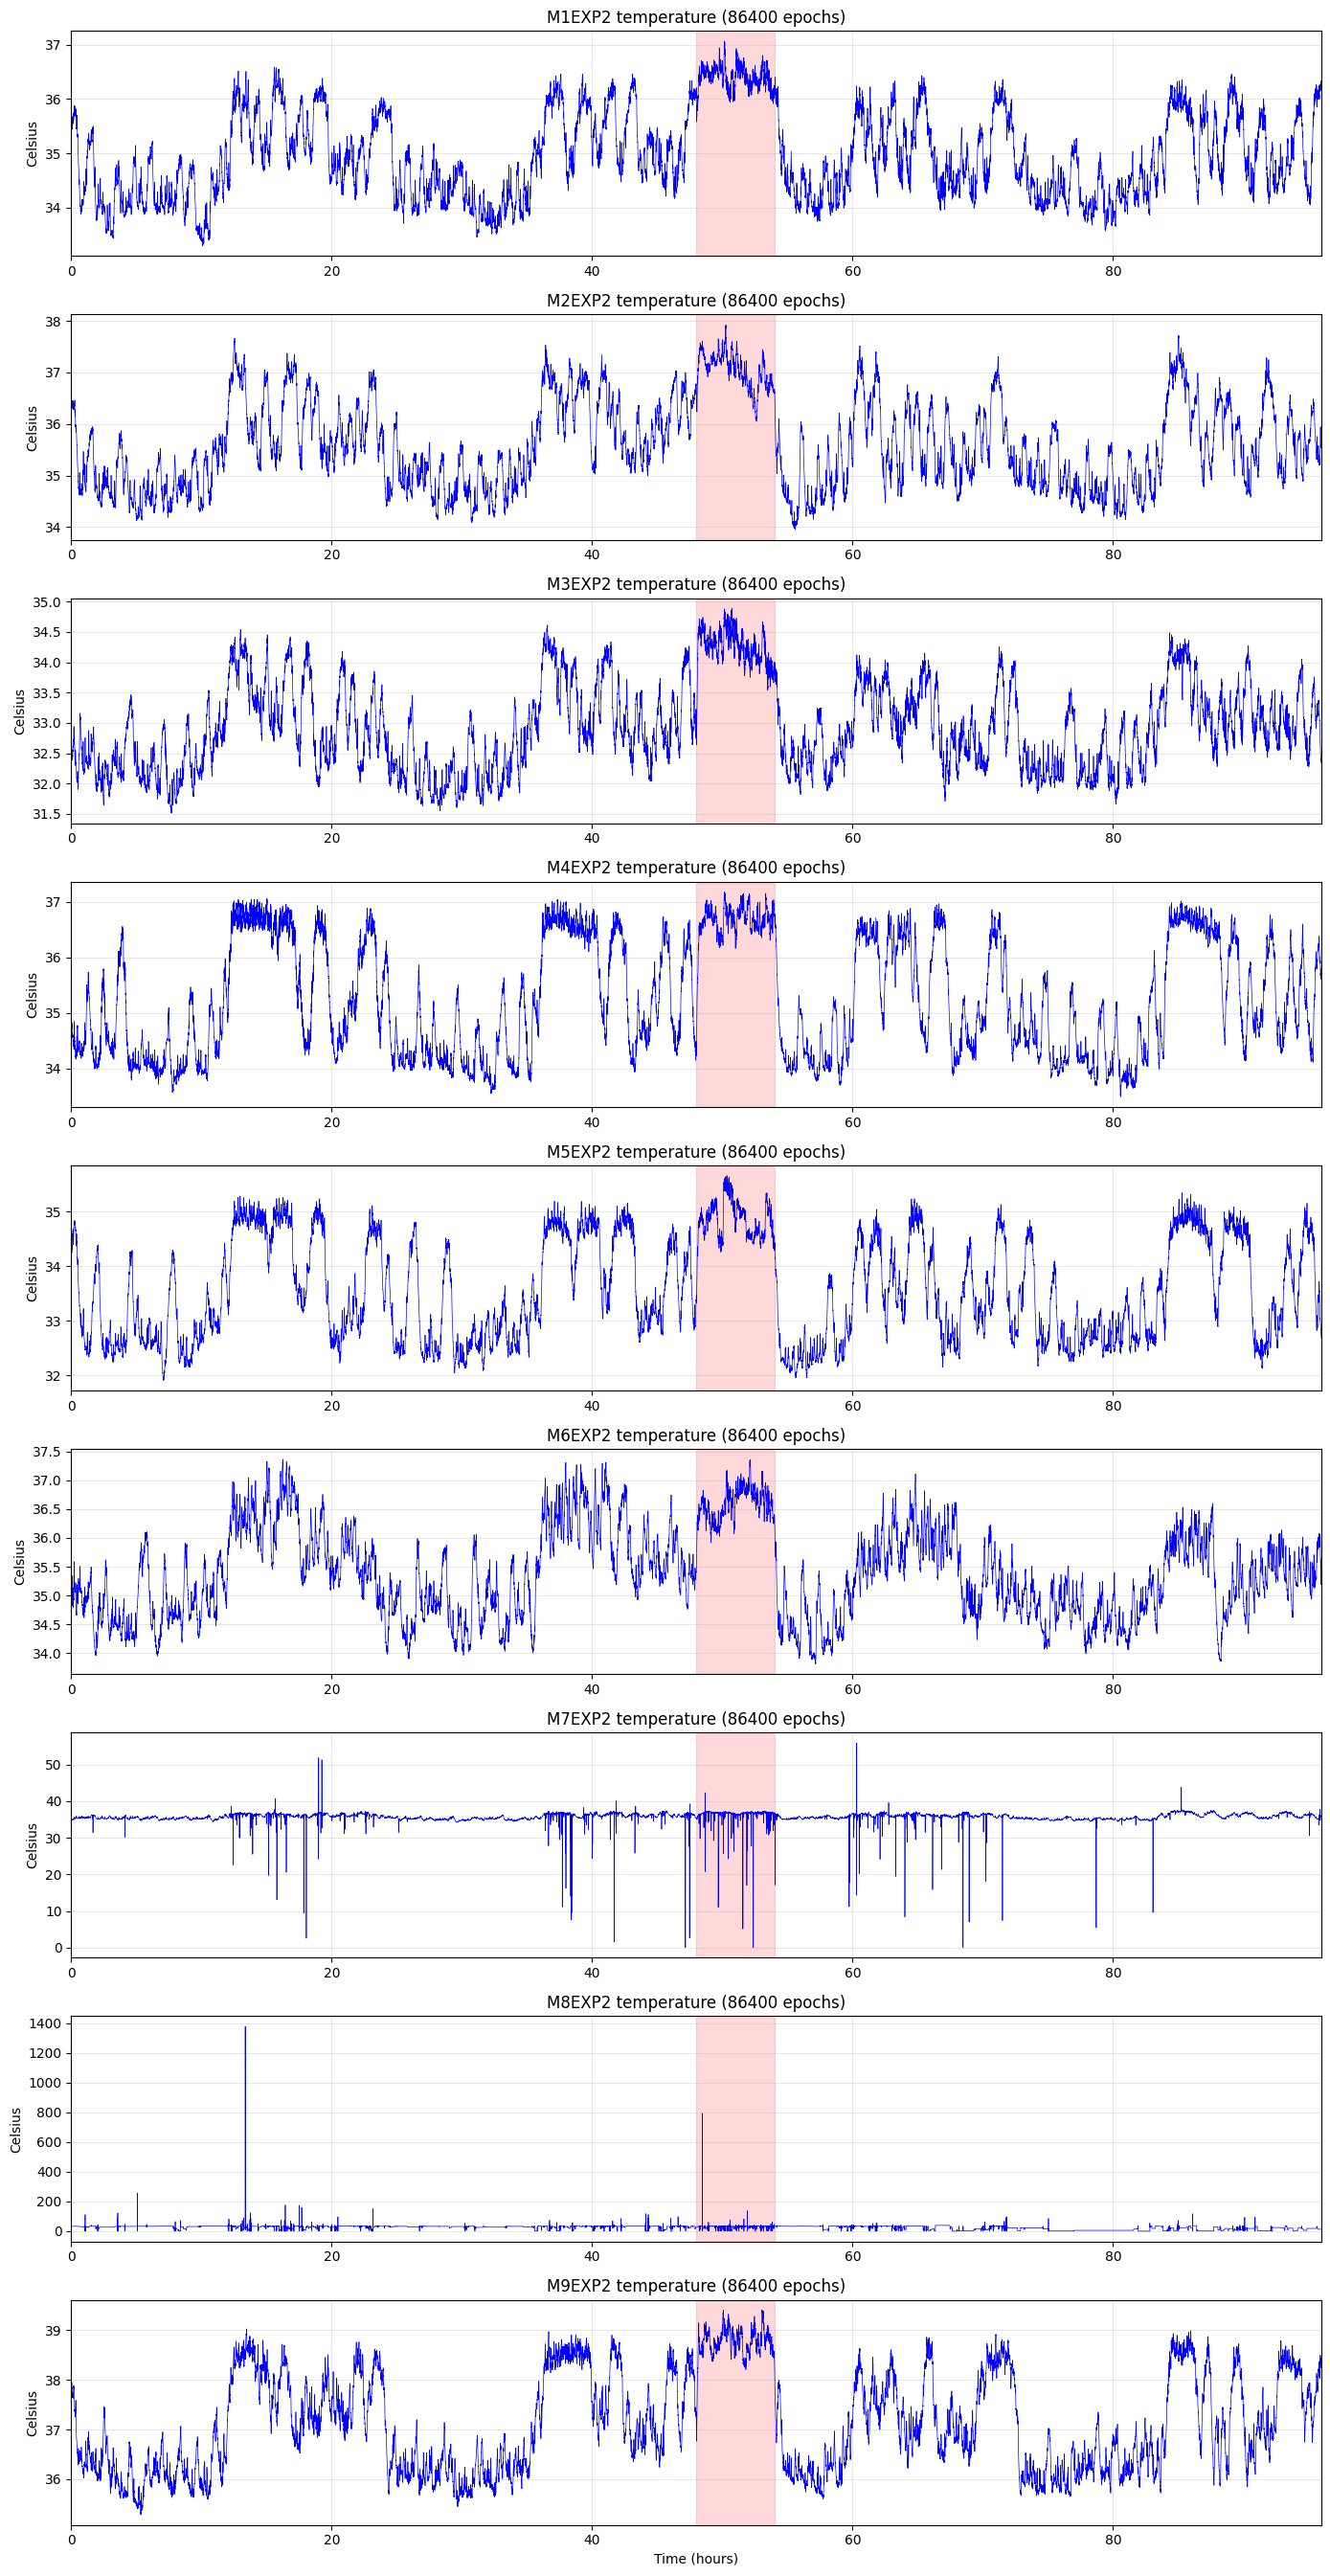

In [ ]:
fig, axes = plt.subplots(len(temp_files), 1, figsize=(14, 3 * len(temp_files)), sharex=False)
if len(temp_files) == 1:
    axes = [axes]

for ax, f in zip(axes, temp_files):
    animal_id = os.path.basename(os.path.dirname(f))
    data = np.fromfile(f, dtype=np.float32)
    time_h = np.arange(len(data)) * 4 / 3600
    ax.plot(time_h, data, linewidth=0.5, color='blue')
    ax.set_ylabel('Celsius')
    ax.set_title(f'{animal_id} temperature (86400 epochs)')
    ax.set_xlim(0, 96)
    ax.grid(True, alpha=0.3)
    ax.axvspan(48, 54, alpha=0.15, color='red', label='Sleep Deprivation') # stated in data_descriptor

axes[-1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.show()


In [ ]:
# comparing converted data to original data for M4EXP2
scores, _, _, _, temp_raw = readbinary_dat('data/M4EXP2.dat')
temp_bin = np.fromfile('data/converted/M4EXP2/M4EXP2_Temperature.bin', dtype=np.float32)

np.allclose(temp_raw, temp_bin) # checking if identical

Read data/M4EXP2.dat: 86400 epochs, temp recorded: True


True